# Pricing autocalls with a stochastic-volatility model built from the stride up — v2

### An idiot's guide, written for model validation. Same market, same product, one residual law swapped.

This is the second edition of the guide. The first built **LogVar2FJ v1**: a two-factor log-variance
state with leverage and a Poisson co-jump residual, priced through a one-step-survival Monte Carlo.
This edition builds **v2**, which keeps the state, the leverage, the OSS pricer and every validation
gate, and replaces the residual — the part of each return that leverage does not explain — with a
**normal-inverse-Gaussian (NIG) increment on the variance clock**. Everything else the first edition
taught us is folded in: the forward-variance curve is stored as the market's object with the Jensen
term derived inside the model, the curve is flat per segment, the parameters are sized under the
pricing measure, the idiosyncratic share is a dial with a floor, and forward skew is a separate target
with a calendar-time lever. Still only `numpy`, `scipy`, `pandas`, `matplotlib`; still a few minutes.

To keep the comparison honest, the market surface, the observation grid, the product, the path counts
and the seeds are the ones the first edition used, and the last section puts the two editions' numbers
side by side.

**Why swap the residual.** v1's residual was a Gaussian with a Poisson count mixed in: given the
count, the return is Gaussian, and counts add across steps. That worked, but the jump intensity λ was
not identified by vanillas, so it had to be fixed by a rule, re-derived per segment of the curve, and
excluded from the Greeks. NIG is the same idea with a *continuous* mixer — an inverse-Gaussian time
change of a Gaussian — which is infinitely divisible in its clock (so it composes exactly), has two
identified shape parameters (α for convexity, β for skew), a martingale drift that is forced rather
than fitted, a closed-form European oracle, and no parameter the Greeks cannot see. The price is one
monotone scalar root per path per observation date, for the mixer's quantile.

**Contents**
1. The product
2. The estimator problem and one-step survival (unchanged)
3. The market, its variance-swap strip, and the stride contract
4. Building the model: state → curve → cap → leverage → NIG residual → mixer → block → stride
5. Calibration: OTM vanillas by conditional Black, identification, the staged fit, the forward-variance check, sizing, forward skew
6. Pricing the autocall
7. The validation gates
8. v1 and v2 side by side, and what to remember


In [1]:
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from scipy.stats import norm, norminvgauss, ks_2samp
from scipy.optimize import brentq, least_squares

Phi, Phinv = norm.cdf, norm.ppf
DAYS = 252
pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (9, 4); plt.rcParams['axes.grid'] = True

def black(F, K, sd):
    """Undiscounted Black call with a TOTAL standard deviation sd."""
    sd = np.maximum(sd, 1e-12)
    d1 = (np.log(F / K) + 0.5 * sd ** 2) / sd
    return F * Phi(d1) - K * Phi(d1 - sd)

def black_put(F, K, sd):
    sd = np.maximum(sd, 1e-12)
    d1 = (np.log(F / K) + 0.5 * sd ** 2) / sd
    return K * Phi(sd - d1) - F * Phi(-d1)

def implied_vol_otm(price, F, K, T, is_put):
    """Annualised implied vol from the OUT-OF-THE-MONEY instrument's price. Pricing the OTM put per path,
    rather than a call minus the forward, avoids a Monte-Carlo cancellation that made deep wings unreadable."""
    if price <= 1e-12:
        return np.nan
    f = (lambda v: black_put(F, K, v * np.sqrt(T)) - price) if is_put else (lambda v: black(F, K, v * np.sqrt(T)) - price)
    return brentq(f, 1e-4, 5.0)

def se(x):
    return x.std() / np.sqrt(len(x))


## 1. The product

Unchanged from the first edition: a 3-year **autocall** with monthly observations, trigger 100%, an
accrued coupon $j\cdot c$ with $c = 2\%$ per period paid on the first observation at or above the
trigger, and a short **put** at maturity below a 70% barrier if never called. Rates and dividends are
zero so that the numbers are about the model. What drives its value is the same two things: the
survival probabilities at each observation (a strip of digitals) and the put conditional on never
having fired — a *forward smile*, not today's.


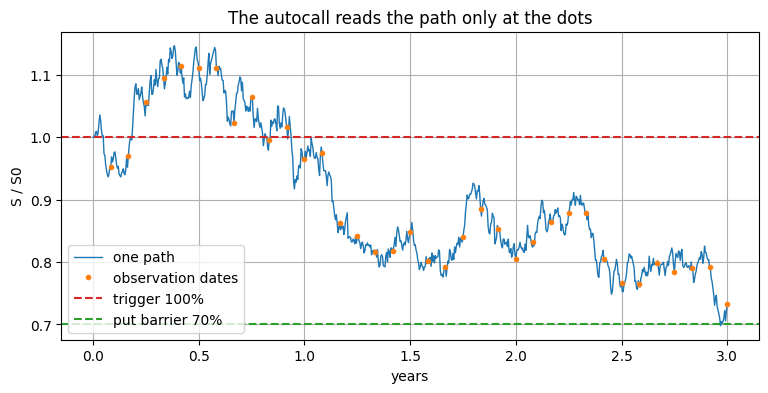

In [2]:
OBS_DAYS, N_OBS = 21, 36
TRIGGER, BARRIER, COUPON = 1.00, 0.70, 0.02
rng = np.random.default_rng(0)
days = np.arange(OBS_DAYS * N_OBS + 1)
path = np.exp(np.cumsum(np.r_[0.0, 0.20 * np.sqrt(1 / DAYS) * rng.standard_normal(OBS_DAYS * N_OBS) - 0.5 * 0.04 / DAYS]))
obs = np.arange(1, N_OBS + 1) * OBS_DAYS
plt.plot(days / DAYS, path, lw=1, label='one path'); plt.plot(obs / DAYS, path[obs], 'o', ms=3, label='observation dates')
plt.axhline(TRIGGER, color='C3', ls='--', label='trigger 100%'); plt.axhline(BARRIER, color='C2', ls='--', label='put barrier 70%')
plt.xlabel('years'); plt.ylabel('S / S0'); plt.legend(loc='lower left'); plt.title('The autocall reads the path only at the dots'); plt.show()


## 2. The estimator problem, and one-step survival

Also unchanged, and repeated because the whole design hangs on it. Brute-force Monte Carlo samples the
fire/survive coin at each observation; the coupon strip is then a sum of indicators and its delta is
noise. One-step survival (OSS) integrates the coin analytically: if the interval return is
$R\sim N(m,s^2)$ and survival means $R < x_{\text{cap}} = \log(K/S)$,

$$p=\Phi\!\left(\tfrac{x_{\text{cap}}-m}{s}\right),\qquad R_{\text{surv}} = m + s\,\Phi^{-1}(u\,p),$$

the fired mass $L(1-p)$ pays the coupon, the survivor continues with weight $Lp$ from the truncated
draw, and the put on the survivors is a lognormal partial moment. Unbiased for the same quantity, and
smooth in the state. **The requirement it creates**: the return over an observation interval must be
Gaussian, conditional on whatever has already been sampled, with a per-path mean and variance. In v2
the "whatever" gains one member — the residual's mixer — and nothing else changes.


In [3]:
def autocall_oss_from_stats(M, S2, u_block, S0, trigger, barrier, coupon):
    """OSS pricer on per-path block Gaussians (M, S2). Identical to the first edition's."""
    n, nb = M.shape
    logS = np.full(n, np.log(S0)); Lw = np.ones(n); pv = np.zeros(n)
    for j in range(nb):
        m, sd = M[:, j], np.sqrt(S2[:, j])
        x_cap = np.log(trigger) - logS
        p = Phi((x_cap - m) / sd)
        pv += Lw * (1.0 - p) * (j + 1) * coupon
        if j == nb - 1:
            zB = (np.log(barrier) - logS - m) / sd
            pv += Lw * (np.exp(logS + m + 0.5 * sd ** 2) * Phi(zB - sd) - Phi(zB))
        Lw = Lw * p
        u = np.clip(u_block[:, j] * p, 1e-16, 1 - 1e-16)
        logS = logS + m + sd * Phinv(u)
    return pv

def autocall_brute_from_returns(R, S0, trigger, barrier, coupon):
    n, nb = R.shape
    logS = np.log(S0) + np.cumsum(R, axis=1)
    alive = np.ones(n, bool); pv = np.zeros(n)
    for j in range(nb):
        fired = alive & (logS[:, j] >= np.log(trigger))
        pv += fired * (j + 1) * coupon
        alive &= ~fired
    ST = np.exp(logS[:, -1])
    pv += alive * np.where(ST < barrier, ST - 1.0, 0.0)
    return pv

SIGMA_BS, N = 0.20, 2 ** 16
dt_block = OBS_DAYS / DAYS
rng = np.random.default_rng(1)
u_block = rng.uniform(size=(N, N_OBS)); eps = rng.standard_normal((N, N_OBS))
M_bs = np.full((N, N_OBS), -0.5 * SIGMA_BS ** 2 * dt_block); S2_bs = np.full((N, N_OBS), SIGMA_BS ** 2 * dt_block)
pv_oss = autocall_oss_from_stats(M_bs, S2_bs, u_block, 1.0, TRIGGER, BARRIER, COUPON)
pv_brute = autocall_brute_from_returns(M_bs + np.sqrt(S2_bs) * eps, 1.0, TRIGGER, BARRIER, COUPON)
pd.DataFrame({'value': [pv_brute.mean(), pv_oss.mean()], 'std error': [se(pv_brute), se(pv_oss)]},
             index=['brute force (Black-Scholes)', 'one-step survival (Black-Scholes)']).round(5)


,value,std error
brute force (Black-Scholes),0.0389,0.0007
one-step survival (Black-Scholes),0.0377,0.0003


## 3. The market, its variance-swap strip, and the stride contract

### 3.1 The same stylised surface

The SVI surface of the first edition, quote for quote: 35 implied vols at 1m–2y and 80–120%.

New in this edition is a second market object read off the same smiles: the **variance-swap strip**,
by static replication of the log contract, $\sigma_{VS}^2 T = 2\!\int P(K)/K^2\,dK + 2\!\int C(K)/K^2\,dK$.
It matters because in v2 the model's stored curve is $\xi(t) = E_0[h_t]$, the expected forward
variance, which is exactly what a variance swap pays. So the curve the calibrator finds can be checked
against a market-observable strip, not only against ATM vols (section 5.3). On this stylised surface
the variance-swap vol sits above the ATM vol by 0.7 points at one month and 4.7 at two years — a
larger gap than a typical index shows (the SVI wings are generous), and the model will have to carry
it with vol-of-vol.


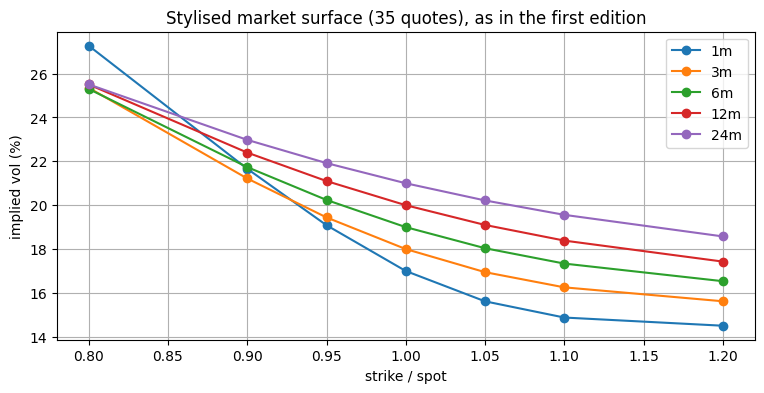

,ATM vol (%),var-swap vol (%),gap (vol pts),forward var-swap vol per segment (%)
1m,17.0,17.67,0.67,17.67
3m,18.0,19.21,1.21,19.94
6m,19.0,21.06,2.06,22.76
12m,20.0,23.56,3.56,25.82
24m,21.0,25.73,4.73,27.73


In [4]:
def svi_surface(strikes, T, atm, vol_skew, rho=-0.8, sig=None):
    k = np.log(strikes); out = []
    for i, (t, a_vol, s_v) in enumerate(zip(T, atm, vol_skew)):
        sg = (0.25 * np.sqrt(t) + 0.06) if sig is None else sig[i]
        b = 2.0 * s_v * a_vol * t / rho; a = a_vol ** 2 * t - b * sg
        w = a + b * (rho * k + np.sqrt(k ** 2 + sg ** 2))
        out.append(np.sqrt(np.maximum(w, 1e-8) / t))
    return np.array(out)

def varswap_strip(T_list, atm, vol_skew, rho=-0.8, K_lo=0.3, K_hi=3.0, n=4000):
    """Model-free variance-swap total variances from the smile by log-contract replication (F = 1)."""
    K = np.linspace(K_lo, K_hi, n); out = []
    for i, T in enumerate(T_list):
        iv = svi_surface(K, [T], [atm[i]], [vol_skew[i]], rho)[0]; sd = iv * np.sqrt(T)
        price = np.where(K < 1.0, black_put(1.0, K, sd), black(1.0, K, sd))
        out.append(2.0 * np.trapezoid(price / K ** 2, K))
    return np.array(out)

MATS = [1, 3, 6, 12, 24]; T_MATS = np.array(MATS) * OBS_DAYS / DAYS
STRIKES = np.array([0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20])
ATM = np.array([0.17, 0.18, 0.19, 0.20, 0.21]); VOL_SKEW = np.array([-0.35, -0.25, -0.22, -0.20, -0.17])
MARKET = svi_surface(STRIKES, T_MATS, ATM, VOL_SKEW)
VS_TOTAL = varswap_strip(T_MATS, ATM, VOL_SKEW)                      # sigma_VS^2 * T at each maturity
VS_FWD = np.diff(np.r_[0.0, VS_TOTAL]) / np.diff(np.r_[0.0, T_MATS])  # flat forward variance per segment

for i, m in enumerate(MATS):
    plt.plot(STRIKES, 100 * MARKET[i], 'o-', label=f'{m}m')
plt.xlabel('strike / spot'); plt.ylabel('implied vol (%)'); plt.legend(); plt.title('Stylised market surface (35 quotes), as in the first edition'); plt.show()
pd.DataFrame({'ATM vol (%)': 100 * ATM, 'var-swap vol (%)': 100 * np.sqrt(VS_TOTAL / T_MATS),
              'gap (vol pts)': 100 * (np.sqrt(VS_TOTAL / T_MATS) - ATM), 'forward var-swap vol per segment (%)': 100 * np.sqrt(VS_FWD)},
             index=[f'{m}m' for m in MATS]).round(2)


### 3.2 The stride contract, v2

The seven requirements are the first edition's: (a) survival probability in closed form; (b) the
truncated draw as a closed-form quantile; (c) closed-form partial moments; (d) the state carried
exactly; (e) the martingale exact; (f) one primitive for any interval; (g) smooth in everything.

(a)–(c) still force the return to be **Gaussian given everything sampled before it**, and (d) still
forces the variance state to be drawn before the return, independent of its own shock. What v2 adds
is a precise statement of *what may be sampled first*: anything **infinitely divisible in the
variance clock**, so that (f) survives — a month cut into weeks must have the same residual law once
the clock is the same. A Gaussian mixture with a Poisson count qualifies (v1); a Gaussian mixture
with an inverse-Gaussian mixer qualifies (v2). What does not qualify is any residual whose shape
depends on the step, which is why the grid-native model's quadratic response stayed out of both
editions. One clarification of (b): the return's CDF given the mixer is still Φ and its inverse still
Φ⁻¹; the mixer's own quantile is a monotone scalar root once per block, the only root in the model.


## 4. Building the model, slowly

### 4.1 The variance state, and the curve stored as the market's object

Two exact Ornstein–Uhlenbeck steps in log variance — a slow factor $\ell$ reverting to a
deterministic level $L^*(t)$ and a fast factor $s$ reverting to zero — with $h = e^{\ell+s}$:

$$\ell_{k+1} = L^*(t_{k+1}) + \phi_\ell(\ell_k - L^*(t_k)) + w_\ell\eta^\ell_k,\qquad
s_{k+1} = \phi_s s_k + w_s\eta^s_k,\qquad \phi_i = e^{-\kappa_i\delta},\ w_i = \sigma_i\sqrt{\tfrac{1-\phi_i^2}{2\kappa_i}}.$$

**What changed from v1: the curve is $\xi(t) = E_0[h_t]$, and $L^*$ is derived from it.** Because
$\ell_t + s_t$ is Gaussian, $E[e^{\ell+s}] = e^{L^* + \frac12\text{Var}(\ell+s)}$, so storing $L^*$
makes the stored curve *not* the expected variance — the Jensen term moves it, and every change of
vol-of-vol in a calibration drags the ATM level with it. Instead we store $\xi$ and set

$$L^*(t) = \log\xi(t) - \tfrac12 V(t),\qquad V(t) = \tfrac{\sigma_\ell^2}{2\kappa_\ell}(1-e^{-2\kappa_\ell t}) + \tfrac{\sigma_s^2}{2\kappa_s}(1-e^{-2\kappa_s t}),$$

so that $E_0[h_t] = \xi(t)$ exactly before the cap, whatever the vol-of-vol. Three consequences the
first edition lacked: the curve is comparable to a variance-swap strip (3.1) and to component-HN's
level; the ATM level is invariant to $\sigma_s, \sigma_\ell$ by construction, so the calibrator's
inner solve for the curve is near-identity; and the curve is **piecewise-constant per segment**
between ATM expiries — flat forward variance, the shape var-swap strips are quoted in — which kills
the pillar-to-pillar zig-zag a piecewise-linear curve produces when segment integrals are matched
one by one (a recurrence with multiplier −1; measured on a real fit, the pillars read 14.6, 5.5,
20.0, 10.8, 13.4 vol against a market strip of 16.0, 12.7, 15.7, 19.8, 17.5). Inside a segment
$L^*(t)$ is *not* flat: it carries $-\tfrac12 V(t)$, which is what makes the expected variance flat
where the market says it is.


In [5]:
P = dict(kappa_l=0.5, sigma_l=1.0, rho_l=-0.4,        # slow factor
         kappa_s=6.0, sigma_s=2.4, rho_s=-0.75,       # fast factor
         alpha=44.0, beta=-22.0,                      # NIG residual: tail thickness and skew (4.4)
         cap_a=np.log(100.0), cap_beta=0.25)          # the cap (4.2)
N_SUB = 3                                             # internal steps per 21-day block (7 business days), as in v1

class Grid:
    def __init__(self, block_days=OBS_DAYS, n_blocks=N_OBS, n_sub=N_SUB):
        self.block_days, self.n_blocks, self.n_sub = block_days, n_blocks, n_sub
        self.dt = block_days / DAYS / n_sub; self.n_steps = n_blocks * n_sub
        self.t = np.arange(self.n_steps + 1) * self.dt; self.block_end_t = np.arange(1, n_blocks + 1) * block_days / DAYS

def ou_coeffs(P, dt):
    phi_l, phi_s = np.exp(-P['kappa_l'] * dt), np.exp(-P['kappa_s'] * dt)
    return phi_l, phi_s, P['sigma_l'] * np.sqrt((1 - phi_l ** 2) / (2 * P['kappa_l'])), P['sigma_s'] * np.sqrt((1 - phi_s ** 2) / (2 * P['kappa_s']))

def state_var(P, t):
    """Var_0(ell_t + s_t) from the deterministic initial state: the Jensen term."""
    t = np.asarray(t, float)
    return (P['sigma_l'] ** 2 / (2 * P['kappa_l']) * (1 - np.exp(-2 * P['kappa_l'] * t))
            + P['sigma_s'] ** 2 / (2 * P['kappa_s']) * (1 - np.exp(-2 * P['kappa_s'] * t)))

def xi_on_grid(grid, seg_end_t, seg_xi):
    """Piecewise-constant forward variance on the internal grid (segments end at the ATM expiries)."""
    idx = np.searchsorted(seg_end_t, grid.t, side='left')
    return np.asarray(seg_xi, float)[np.clip(idx, 0, len(seg_xi) - 1)]

def Lstar_on_grid(grid, P, xi_grid):
    return np.log(xi_grid) - 0.5 * state_var(P, grid.t)

def stationary_logvol_sd(P):
    return 0.5 * np.sqrt(P['sigma_s'] ** 2 / (2 * P['kappa_s']) + P['sigma_l'] ** 2 / (2 * P['kappa_l']))

# Jensen gate: E[exp(ell + s)] = xi at 1y from the state alone, at a flat xi = 4%
T = 1.0; n = 2 ** 18; rng = np.random.default_rng(2)
Lstar_1y = np.log(0.04) - 0.5 * state_var(P, T)
vl = P['sigma_l'] ** 2 / (2 * P['kappa_l']) * (1 - np.exp(-2 * P['kappa_l'] * T)); vs = P['sigma_s'] ** 2 / (2 * P['kappa_s']) * (1 - np.exp(-2 * P['kappa_s'] * T))
h = np.exp(Lstar_1y + np.sqrt(vl) * rng.standard_normal(n) + np.sqrt(vs) * rng.standard_normal(n))
print(f"E[h_1y] with L* derived from xi = 4%:  {h.mean():.5f}   (target 0.04000, se {se(h):.5f})")
print(f"without the Jensen term (L = log xi):  {np.exp(np.log(0.04) + np.sqrt(vl)*rng.standard_normal(n) + np.sqrt(vs)*rng.standard_normal(n)).mean():.4f}   ({np.exp(0.5*state_var(P,T)):.2f}x too high)")
print(f"stationary sd of log-vol at these parameters: {stationary_logvol_sd(P):.2f}   (VIX options imply 0.5-0.8 at one year)")


E[h_1y] with L* derived from xi = 4%:  0.04015   (target 0.04000, se 0.00011)
without the Jensen term (L = log xi):  0.0698   (1.74x too high)
stationary sd of log-vol at these parameters: 0.61   (VIX options imply 0.5-0.8 at one year)


### 4.2 The cap: structural, and not a floor

Unchanged in purpose, moved in level. A lognormal variance has $E[S^p]=\infty$ for $p>1$; the return
reads $e^{\text{cap}(\ell+s)}$ with $\text{cap}(x) = a - \beta_c\,\text{softplus}((a-x)/\beta_c)$ and
the state is never capped. The first edition set $a = \log 16$ (400% vol); with parameters sized under
the pricing measure (log-vol spread 0.6–0.9) five-sigma path-days reach 700%, so $a = \log 100$ now —
the rule is $a = \max(\log 100,\ L^*(0) + 6 s_\infty)$ with $s_\infty$ the stationary sd of
log-variance. The bias is closed form, $x - \text{cap}(x) = \beta_c\log(1+e^{-(a-x)/\beta_c})$: invisible
below 250% vol, and the headroom diagnostic in section 5 says how much mass ever comes near it.


In [6]:
def cap(x, a, beta):
    return a - beta * np.logaddexp(0.0, (a - x) / beta)
vol_pct = np.array([20, 60, 150, 250, 400, 700, 1000]); x = np.log((vol_pct / 100) ** 2)
pd.DataFrame({'vol (%)': vol_pct, 'log-variance x': x.round(2), 'bias x - cap(x)': [f'{v:.1e}' for v in (x - cap(x, P['cap_a'], P['cap_beta']))]})


,vol (%),log-variance x,bias x - cap(x)
0,20,-3.22,6.7e-15
1,60,-1.02,4.2e-11
2,150,0.81,6.4e-08
3,250,1.83,3.8e-06
4,400,2.77,1.6e-04
5,700,3.89,1.4e-02
6,1000,4.61,1.7e-01


### 4.3 Leverage, and the variance budget

One internal step reads the **budget** $V_k = \delta\,e^{\text{cap}(\ell_k+s_k)}$ from the state at
the step start (predictable, requirement (d)). Two of the step's shocks are the variance shocks, and
they enter the return with the leverage weights:

$$m_k^{\text{lev}} = b_k\delta + \rho_\ell\sqrt{V_k}\,\eta^\ell_k - \tfrac12\rho_\ell^2V_k
+ \rho_s\sqrt{V_k}\,\eta^s_k - \tfrac12\rho_s^2V_k .$$

Each leverage piece has $E[e^{\cdot}]=1$ per path, so the martingale is exact on that part with no
correction, exactly as in v1. Together they spend $(\rho_\ell^2+\rho_s^2)V_k$ of the budget. The share
that is left,

$$c = 1-\rho_\ell^2-\rho_s^2,$$

is the **idiosyncratic share**: the part of the variance that the variance state never sees, the shock
the truncation acts on. It is a dial with two ends — $c=1$ is a pure Lévy return on the clock, $c\to0$
is GARCH (Heston–Nandi's one-step return/variance correlation is $-0.99$) — and a structural floor of
0.12, because OSS efficiency scales like $c^{3/2}$ and skew-per-convexity from leverage like
$\sqrt{1-c}$. The first edition spent $cV_k$ on an independent normal plus Poisson jumps. **This
edition spends the same budget on an NIG increment whose clock is $cV_k$.**

**Sizing under Q.** The leverage products $\rho_s\sigma_s = -1.8$ and $\rho_\ell\sigma_\ell = -0.4$ are
what VIX-vs-SPX daily co-movements imply (≈ −1.9 for the fast one), not what realised-vol regressions
imply (≈ −0.9); the first edition's early draft sized them to the latter and produced half the
market's skew. That episode is why every parameter here has a market reference beside it.


### 4.4 The NIG residual, derived from the martingale condition

Write the residual over a clock $A$ as $X_A \sim NIG(\alpha,\beta,\delta_A,\mu_A)$, with
$\gamma=\sqrt{\alpha^2-\beta^2}$ and the cumulant generating function

$$\log E[e^{uX_A}] = \mu_A u + \delta_A\big(\gamma - \sqrt{\alpha^2-(\beta+u)^2}\big),\qquad |\beta+u|<\alpha.$$

Two conditions fix everything but the shape:

* **Spend exactly the budget.** $\text{Var}(X_A) = \delta_A\alpha^2/\gamma^3 = A$ gives $\delta_A = A\gamma^3/\alpha^2$.
* **Be a martingale.** $E[e^{X_A}] = 1$ gives $\mu_A = \delta_A\big(\sqrt{\alpha^2-(\beta+1)^2}-\gamma\big)$,
  which exists only if $|\beta+1|<\alpha$.

So $\alpha$ is tail thickness and smile convexity, $\beta$ is skew, and the drift is **not a
parameter** — it is forced by no-arbitrage. Both $\delta_A$ and $\mu_A$ are *linear in the clock*,
which is the whole reason the residual composes: cumulants add, so
$X_{A_1}+X_{A_2}\overset{d}{=}X_{A_1+A_2}$ for fixed $(\alpha,\beta)$. A month cut into days has the
same residual law once the clock is the same.

**The optimiser-safe map.** The admissibility region $|\beta|<\alpha$, $|\beta+1|<\alpha$ is awkward
for a solver, so the calibrator works in unconstrained coordinates
$\alpha = \tfrac12+\varepsilon+\text{softplus}(a)$, $\beta = -\tfrac12 + (\alpha-\tfrac12-\varepsilon)\tanh(b)$,
which land inside it for every $(a,b)$. The model asserts admissibility at load and applies no
transform of its own.

**Defaults.** $(\alpha,\beta)=(44,-22)$ is sized on the clock the model actually produces: at
$A = c\,\xi\,T$ with $c=0.28$, $\xi=0.04$, the residual alone has skewness −1.5 and excess kurtosis 5.9
at one month, −0.43 and 0.5 at one year — Lévy scaling, $\propto A^{-1/2}$ and $A^{-1}$ — with a
**conditioning share** $\gamma^2/\alpha^2 = 0.75$, the fraction of the residual's variance that stays
in the Gaussian once the mixer is sampled (4.5). Leverage adds skew on top; calibration decides.


In [7]:
def nig_budget(A, alpha, beta):
    """delta and mu of the NIG increment that spends variance A and has E[e^X] = 1."""
    gamma = np.sqrt(alpha ** 2 - beta ** 2); gamma1 = np.sqrt(alpha ** 2 - (beta + 1.0) ** 2)
    delta = A * gamma ** 3 / alpha ** 2
    return delta, delta * (gamma1 - gamma), gamma

def nig_ab(raw_alpha, raw_skew, eps=1e-6):
    alpha = 0.5 + eps + np.logaddexp(0.0, raw_alpha)
    return alpha, -0.5 + (alpha - 0.5 - eps) * np.tanh(raw_skew)

def nig_ab_inv(alpha, beta, eps=1e-6):
    return np.log(np.expm1(alpha - 0.5 - eps)), np.arctanh((beta + 0.5) / (alpha - 0.5 - eps))

def nig_moments(A, alpha, beta):
    delta, mu, gamma = nig_budget(A, alpha, beta)
    return dict(skew=3 * beta / (alpha * np.sqrt(delta * gamma)), exkurt=3 * (1 + 4 * beta ** 2 / alpha ** 2) / (delta * gamma), abar=alpha * delta)

rows = []
for T_, name in [(1/12, '1m'), (0.25, '3m'), (1.0, '1y')]:
    A = 0.28 * 0.04 * T_; mo = nig_moments(A, P['alpha'], P['beta'])
    rows.append([name, A, mo['skew'], mo['exkurt'], mo['abar']])
display(pd.DataFrame(rows, columns=['horizon', 'clock A', 'residual skewness', 'excess kurtosis', 'shape alpha*delta']).set_index('horizon').round(4))

# the residual's two identities by simulation (scipy's NIG uses a*delta, b*delta, loc, scale=delta)
rng = np.random.default_rng(3); A = 0.28 * 0.04 / 12
delta, mu, gamma = nig_budget(A, P['alpha'], P['beta'])
X = norminvgauss.rvs(P['alpha'] * delta, P['beta'] * delta, loc=mu, scale=delta, size=400_000, random_state=rng)
print(f"variance budget A = {A:.6f}   sample variance {X.var():.6f}")
print(f"E[exp(X)] = {np.exp(X).mean():.5f} +- {se(np.exp(X)):.5f}   (1 by construction)")
print(f"admissibility: |beta| < alpha: {abs(P['beta']) < P['alpha']},  |beta+1| < alpha: {abs(P['beta'] + 1) < P['alpha']}")


,clock A,residual skewness,excess kurtosis,shape alpha*delta
horizon,,,,
1m,0.0009,-1.4878,5.9032,1.1736
3m,0.0028,-0.8590,1.9677,3.5209
1y,0.0112,-0.4295,0.4919,14.0837


variance budget A = 0.000933   sample variance 0.000935
E[exp(X)] = 0.99998 +- 0.00005   (1 by construction)
admissibility: |beta| < alpha: True,  |beta+1| < alpha: True


### 4.5 The mixer: NIG is a Gaussian once you have sampled its clock

The representation that makes OSS work: with $G_A \sim IG(m=\delta_A/\gamma,\ \lambda=\delta_A^2)$
(inverse-Gaussian in mean/shape form),

$$X_A \mid G_A \sim N(\mu_A + \beta G_A,\ G_A).$$

So the block procedure is: walk the state, accumulate the clock $A_j = \sum_{k\in B_j} cV_k$, sample
**one** mixer $G_j$ per block, and then the block return is Gaussian with mean
$M_j = M^{\text{lev}}_j + \mu_{A_j} + \beta G_j$ and variance $\Sigma_j^2 = G_j$. Everything
non-Gaussian has been sampled before the final shock, the end-of-block state is already known, and the
survival truncation is the same Φ and Φ⁻¹ as in section 2.

**The one root.** The IG has a closed-form CDF,
$F(x) = \Phi\big(\sqrt{\lambda/x}(x/m-1)\big) + e^{2\lambda/m}\Phi\big(-\sqrt{\lambda/x}(x/m+1)\big)$,
but no closed-form quantile. Sampling $G$ from a uniform is therefore a monotone scalar root — Newton
with a bracket, warm-started from a lognormal moment match, converging in a handful of iterations,
once per path per block. In production its derivative comes from the implicit function theorem
($\partial G/\partial\theta = -\partial_\theta F/\partial_x F$), which is what keeps vega exact; the
alternative closed-form sampler (Michael–Schucany–Haas) has a parameter-dependent acceptance branch
that breaks pathwise vega and is not used in the pricer. Delta and gamma never see the mixer at all:
it does not depend on spot.

The cells check the quantile against the CDF, the mixture identity against direct NIG draws, and the
semigroup property against a split clock.


In [8]:
def ig_cdf(x, m, lam):
    x = np.maximum(x, 1e-300); r = np.sqrt(lam / x)
    return Phi(r * (x / m - 1.0)) + np.exp(2.0 * lam / m + norm.logcdf(-r * (x / m + 1.0)))

def ig_pdf(x, m, lam):
    x = np.maximum(x, 1e-300)
    return np.sqrt(lam / (2 * np.pi * x ** 3)) * np.exp(-lam * (x - m) ** 2 / (2 * m ** 2 * x))

def ig_quantile(u, m, lam, iters=60, tol=1e-11):
    """Safeguarded Newton on the closed-form IG CDF, iterating only on unconverged elements. The model's one root."""
    u = np.clip(np.asarray(u, float), 1e-12, 1 - 1e-12); shape = u.shape; u = u.ravel()
    m = np.broadcast_to(np.asarray(m, float), shape).ravel().copy(); lam = np.broadcast_to(np.asarray(lam, float), shape).ravel().copy()
    lo = m * 1e-8; hi = m * 200.0 + 200.0 * m ** 2 / lam
    for _ in range(20):
        need = ig_cdf(hi, m, lam) < u
        if not need.any(): break
        hi = np.where(need, hi * 4.0, hi)
    sx = np.sqrt(np.log1p(m / lam))
    x = np.clip(m * np.exp(sx * Phinv(u) - 0.5 * sx ** 2), lo * 2, hi / 2)      # lognormal moment-matched start
    idx = np.arange(u.size)
    for _ in range(iters):
        xi, ui, mi, li = x[idx], u[idx], m[idx], lam[idx]
        F = ig_cdf(xi, mi, li); keep = np.abs(F - ui) >= tol
        if not keep.any(): break
        idx, xi, ui, mi, li, F = idx[keep], xi[keep], ui[keep], mi[keep], li[keep], F[keep]
        f = ig_pdf(xi, mi, li)
        lo[idx] = np.where(F < ui, xi, lo[idx]); hi[idx] = np.where(F > ui, xi, hi[idx])
        x_new = xi - (F - ui) / np.maximum(f, 1e-300)
        bad = ~np.isfinite(x_new) | (x_new <= lo[idx]) | (x_new >= hi[idx])
        x[idx] = np.where(bad, 0.5 * (lo[idx] + hi[idx]), x_new)
    return x.reshape(shape)

def nig_mixer(A, alpha, beta, u):
    """Sample the block's mixer G from a uniform; return G and the forced drift mu_A."""
    delta, mu, gamma = nig_budget(A, alpha, beta)
    return ig_quantile(u, delta / gamma, delta ** 2), mu

rng = np.random.default_rng(4); nn = 400_000
A = 0.28 * 0.04 / 12; delta, mu, gamma = nig_budget(A, P['alpha'], P['beta'])
u = rng.uniform(size=nn); t0 = time.time(); G = ig_quantile(u, delta / gamma, delta ** 2); t_q = time.time() - t0
print(f"quantile round trip max |F(G) - u| = {np.max(np.abs(ig_cdf(G, delta/gamma, delta**2) - u)):.1e}   ({t_q:.2f}s for {nn:,} draws)")
X_mix = mu + P['beta'] * G + np.sqrt(G) * rng.standard_normal(nn)
X_dir = norminvgauss.rvs(P['alpha'] * delta, P['beta'] * delta, loc=mu, scale=delta, size=nn, random_state=rng)
ks_mix = ks_2samp(X_mix, X_dir)
G1, mu1 = nig_mixer(0.4 * A, P['alpha'], P['beta'], rng.uniform(size=nn)); G2, mu2 = nig_mixer(0.6 * A, P['alpha'], P['beta'], rng.uniform(size=nn))
X_split = mu1 + P['beta'] * G1 + np.sqrt(G1) * rng.standard_normal(nn) + mu2 + P['beta'] * G2 + np.sqrt(G2) * rng.standard_normal(nn)
ks_semi = ks_2samp(X_split, X_dir)
print(f"mixture identity vs direct NIG:  KS = {ks_mix.statistic:.4f} (p = {ks_mix.pvalue:.2f})")
print(f"semigroup, clock 0.4A + 0.6A vs A: KS = {ks_semi.statistic:.4f} (p = {ks_semi.pvalue:.2f})")


quantile round trip max |F(G) - u| = 1.0e-11   (0.45s for 400,000 draws)


mixture identity vs direct NIG:  KS = 0.0014 (p = 0.80)
semigroup, clock 0.4A + 0.6A vs A: KS = 0.0016 (p = 0.71)


### 4.6 The walk and the block Gaussian

One loop over internal steps evolves the two states and accumulates, per block, the leverage mean
$M^{\text{lev}}_j$ and the clock $A_j$. At the end of each block the mixer is drawn and the
Gaussian's $(M_j, \Sigma_j^2)$ assembled. Returns are never drawn inside a block; the brute-force
comparison later draws one normal per block from the *same* $(M_j,\Sigma_j)$, so the two estimators
share the variance path and the mixer and differ only in the fire/survive treatment.

Note what the stride now needs from the calibrated model: a curve $\xi$ per segment, two OU factors,
two leverages, and $(\alpha,\beta)$. There is no intensity, no jump size, no co-jump, no compensator
to derive per segment — and no parameter the Greeks cannot reach.


In [9]:
def draws(grid, n_paths, rng, antithetic=True):
    h = n_paths // 2 if antithetic else n_paths
    eta_l = rng.standard_normal((h, grid.n_steps)); eta_s = rng.standard_normal((h, grid.n_steps)); uG = rng.uniform(size=(h, grid.n_blocks))
    if antithetic:
        eta_l = np.concatenate([eta_l, -eta_l]); eta_s = np.concatenate([eta_s, -eta_s]); uG = np.concatenate([uG, 1 - uG])
    n = eta_l.shape[0]
    return dict(eta_l=eta_l, eta_s=eta_s, uG=uG, u_block=rng.uniform(size=(n, grid.n_blocks)), eps=rng.standard_normal((n, grid.n_blocks)))

def bucket_on_grid(grid, bucket_t, values):
    idx = np.searchsorted(bucket_t, grid.t[:-1], side='right') - 1
    return np.asarray(values, float)[np.clip(idx, 0, len(values) - 1)]

def walk(grid, P, Lstar, d, rho_s_t=None, beta_t=None, carry_block=0.0):
    """Walk the state; per block accumulate M_lev and the clock A; draw the mixer; return the block Gaussian (M, S2)."""
    n, ns = d['eta_l'].shape
    rho_s_t = np.full(ns, P['rho_s']) if rho_s_t is None else rho_s_t
    beta_t = np.full(ns, P['beta']) if beta_t is None else beta_t
    phi_l, phi_s, w_l, w_s = ou_coeffs(P, grid.dt)
    ell = np.full(n, Lstar[0]); s = np.zeros(n)
    Mlev = np.zeros((n, grid.n_blocks)); A = np.zeros((n, grid.n_blocks))
    for k in range(ns):
        b = k // grid.n_sub
        V = grid.dt * np.exp(cap(ell + s, P['cap_a'], P['cap_beta']))                       # PREDICTABLE budget
        rs = rho_s_t[k]; c = 1.0 - rs ** 2 - P['rho_l'] ** 2
        Mlev[:, b] += (-0.5 * P['rho_l'] ** 2 * V + P['rho_l'] * np.sqrt(V) * d['eta_l'][:, k]
                       - 0.5 * rs ** 2 * V + rs * np.sqrt(V) * d['eta_s'][:, k])
        A[:, b] += c * V                                                                   # the residual's clock
        s = phi_s * s + w_s * d['eta_s'][:, k]
        ell = Lstar[k + 1] + phi_l * (ell - Lstar[k]) + w_l * d['eta_l'][:, k]
    Mlev = Mlev + carry_block
    beta_b = beta_t[::grid.n_sub][:grid.n_blocks]                                          # bucket boundaries are block boundaries
    G, mu = nig_mixer(A, P['alpha'], beta_b[None, :], d['uG'])
    return dict(M=Mlev + mu + beta_b[None, :] * G, S2=G, Mlev=Mlev, A=A, ell=ell, s=s)

# martingale gate on the raw model at the section-4 parameters, flat xi = 4%
grid = Grid(n_blocks=24); SEG_END = grid.block_end_t[[0, 2, 5, 11, 23]]                     # segment ends at 1m, 3m, 6m, 1y, 2y
Ls = Lstar_on_grid(grid, P, xi_on_grid(grid, SEG_END, np.full(5, 0.04)))
rng = np.random.default_rng(5); d = draws(grid, 2 ** 15, rng); W = walk(grid, P, Ls, d)
cumM, cumS2 = np.cumsum(W['M'], 1), np.cumsum(W['S2'], 1)
rows = []
for jb in [1, 3, 12, 24]:
    F = np.exp(cumM[:, jb - 1] + 0.5 * cumS2[:, jb - 1]); rows.append([f'{jb}m', F.mean() - 1, se(F)])
display(pd.DataFrame(rows, columns=['maturity', 'E[S_T] - 1', 'std error']).set_index('maturity').round(5))
print(f"mean clock per block {W['A'].mean():.5f}, mean mixer {W['S2'].mean():.5f}: conditioning share {W['S2'].mean()/W['A'].mean():.3f} (gamma^2/alpha^2 = {1-(P['beta']/P['alpha'])**2:.3f})")


,E[S_T] - 1,std error
maturity,,
1m,1.0000e-05,0.0003
3m,-5.0000e-05,0.0005
12m,-1.1000e-04,0.0009
24m,-4.0000e-05,0.0013


mean clock per block 0.00093, mean mixer 0.00069: conditioning share 0.750 (gamma^2/alpha^2 = 0.750)


### 4.7 The stride

Unchanged: `autocall_oss_from_stats` from section 2, fed the per-path $(M_j,\Sigma_j)$ that the walk
and the mixer produce. Survival is Φ, the truncated draw Φ⁻¹, the put a lognormal partial moment, and
the state carried is the end-of-block $(\ell, s)$ — determined before the final Gaussian shock, which
is why the carry is exact. The three values handed to any product at an observation date are
$S_{t+\Delta}$, $h_{t+\Delta}=e^{\ell+s}$ and $q_{t+\Delta}=e^{\ell}$.


## 5. Calibration

### 5.1 Vanillas by conditional Black — on the out-of-the-money instrument

Conditional on the shocks and the mixers, $\log S_T$ is Gaussian, so a vanilla is Black's formula
averaged over variance paths — no return sampling, no transform. One implementation lesson from the
first edition is folded in: price the **OTM instrument per path** (a put below spot, a call above)
and invert that, rather than pricing calls everywhere and subtracting the forward. A deep put is
worth $10^{-4}$; the forward's Monte-Carlo noise is $10^{-3}$; the subtraction turned wings into NaNs.


In [10]:
def vanilla_prices(W, S0, maturities_blocks, strikes):
    cumM, cumS2 = np.cumsum(W['M'], axis=1), np.cumsum(W['S2'], axis=1); out = {}
    for jb in maturities_blocks:
        F = S0 * np.exp(cumM[:, jb - 1] + 0.5 * cumS2[:, jb - 1]); sd = np.sqrt(cumS2[:, jb - 1])
        out[jb] = np.array([(black_put(F, K * S0, sd) if K < 1.0 else black(F, K * S0, sd)).mean() for K in strikes])
    return out

def model_smile(W, S0, grid, maturities_blocks, strikes):
    prices = vanilla_prices(W, S0, maturities_blocks, strikes)
    return {jb: np.array([implied_vol_otm(p, S0, K * S0, grid.block_end_t[jb - 1], K < 1.0) for p, K in zip(prices[jb], strikes)]) for jb in maturities_blocks}

def skew_90_110(iv, strikes=STRIKES):
    return 100 * (iv[list(strikes).index(0.9)] - iv[list(strikes).index(1.1)])

def bfly_90_110(iv, strikes=STRIKES):
    return 100 * (0.5 * (iv[list(strikes).index(0.9)] + iv[list(strikes).index(1.1)]) - iv[list(strikes).index(1.0)])

# conditional Black vs sampling S_T on the 1y 90% put, same walk
jb, K = 12, 0.9
cond = black_put(np.exp(cumM[:, jb - 1] + 0.5 * cumS2[:, jb - 1]), K, np.sqrt(cumS2[:, jb - 1]))
ST = np.exp(cumM[:, jb - 1] + np.sqrt(cumS2[:, jb - 1]) * rng.standard_normal(len(cond))); brute = np.maximum(K - ST, 0.0)
pd.DataFrame({'price': [cond.mean(), brute.mean()], 'std error': [se(cond), se(brute)]}, index=['conditional Black (per-path put)', 'sample S_T and pay off']).round(5)


,price,std error
conditional Black (per-path put),0.0376,0.0004
sample S_T and pay off,0.0372,0.0005


### 5.2 What identifies what

| surface feature | parameter it pins | comment |
|---|---|---|
| ATM term structure / variance-swap strip | the curve $\xi$ per segment | near-identity, since $E[h]=\xi$ by construction |
| 1–3m skew and the 70–80% wing | $\beta$, $\alpha$ | the residual's job; identified, unlike v1's $(\lambda,\mu_J,\sigma_J)$ |
| 3–12m skew and convexity | $\rho_s,\sigma_s$ | leverage covariance and vol-of-vol |
| skew beyond one year | $\rho_\ell,\sigma_\ell$ | fitted only when a wing at ≥ 18m exists — here it does (2y); floor $\sigma_\ell \ge 0.3$ |
| mean-reversion speeds | **not identified** | priors |
| skew split between $\beta$ and $\rho_s\sigma_s$ | **weakly identified** | the two give the same spot skew; only forward smiles separate them (5.5) |
| forward skew | **not identified** | section 5.5 |

Three soft constraints in the objective, each a statement about the model rather than a tuning knob:
$c \ge 0.12$ (the dial's floor); the residual's conditioning share $\gamma^2/\alpha^2 \ge 0.4$, i.e.
$|\beta|/\alpha \le 0.77$, because past that the mixer carries the return and the OSS advantage goes
with it; and the stationary log-vol sd within $[0.4, 0.9]$. There is no jump-share box and no
intensity rule any more; the residual's shape is simply fitted.


In [11]:
C_MIN, COND_MIN, SD_LO, SD_HI = 0.12, 0.4, 0.4, 0.9
FIT_NAMES = ['raw_alpha', 'raw_skew', 'rho_s', 'sigma_s', 'rho_l', 'sigma_l']
BOUNDS = [(-6, -1)] * 5 + [(-2, 500), (-3, 3), (-0.90, 0.0), (0.5, 5.0), (-0.6, 0.6), (0.3, 3.0)]
WEIGHTS = np.where(STRIKES[None, :] <= 0.9, 2.0, 1.0) * np.ones((len(MATS), 1))

def unpack(x, P0, grid):
    nk = len(SEG_END); Pn = dict(P0)
    Pn['alpha'], Pn['beta'] = nig_ab(x[nk], x[nk + 1])
    Pn.update(rho_s=x[nk + 2], sigma_s=x[nk + 3], rho_l=x[nk + 4], sigma_l=x[nk + 5])
    return Pn, Lstar_on_grid(grid, Pn, xi_on_grid(grid, SEG_END, np.exp(x[:nk])))

def residuals(x, P0, grid, d, market_iv, mask):
    Pn, Ln = unpack(x, P0, grid)
    ivs = model_smile(walk(grid, Pn, Ln, d), 1.0, grid, MATS, STRIKES)
    r = ((np.array([ivs[m] for m in MATS]) - market_iv) * WEIGHTS)[mask]
    r = np.where(np.isnan(r), 0.5, r)
    c = 1 - Pn['rho_s'] ** 2 - Pn['rho_l'] ** 2; cond = 1 - (Pn['beta'] / Pn['alpha']) ** 2; sd = stationary_logvol_sd(Pn)
    return np.append(r, [5 * max(0, C_MIN - c), 5 * max(0, COND_MIN - cond), 2 * max(0, sd - SD_HI), 2 * max(0, SD_LO - sd)])

def _fill(x0, free, y):
    x = x0.copy(); x[free] = y; return x

def calibrate(x0, P0, grid, d, market_iv, mask, free, max_nfev):
    x0 = np.array(x0, float); free = np.array(free, bool)
    f = lambda y: residuals(_fill(x0, free, y), P0, grid, d, market_iv, mask)
    lb = np.array([b[0] for b in BOUNDS])[free]; ub = np.array([b[1] for b in BOUNDS])[free]
    res = least_squares(f, x0[free], bounds=(lb, ub), max_nfev=max_nfev, xtol=1e-6, ftol=1e-6, diff_step=1e-3)
    return _fill(x0, free, res.x), res


### 5.3 The staged fit, and the forward-variance check

Stage 1 moves the curve only, starting from the ATM forward variances; stage 2 moves everything;
stage 3 polishes the curve. Fixed draws throughout (common random numbers), 8,000 antithetic paths on
the 7-day internal step, as in the first edition. Finite-difference Jacobian here; AAD in production.

The new check afterwards: the fitted $\xi$ per segment against the **market's variance-swap strip**
from 3.1. In v1 the curve was a log-level with a Jensen share and a jump variance to add back before
it meant anything; here $\xi$ *is* the expected forward variance, so it should sit on the replicated
strip within the wing extrapolation's uncertainty (on this surface it lands within 3% on the first
four segments and 9% high on the 2y segment, where the replicated strip leans most on the extrapolated
wings). That is the forward-variance semantics the model now has, verified against a market object
rather than asserted.


In [12]:
grid = Grid(n_blocks=24); d_cal = draws(grid, 8000, np.random.default_rng(7)); mask_all = np.ones(MARKET.shape, bool)
tv = ATM ** 2 * T_MATS; fv_atm = np.diff(np.r_[0.0, tv]) / np.diff(np.r_[0.0, T_MATS])
ra, rs = nig_ab_inv(P['alpha'], P['beta'])
x0 = np.r_[np.log(fv_atm), ra, rs, P['rho_s'], P['sigma_s'], P['rho_l'], P['sigma_l']]

t0 = time.time(); x1, r1 = calibrate(x0, P, grid, d_cal, MARKET, mask_all, [True] * 5 + [False] * 6, max_nfev=20)
print(f"stage 1 (curve only):   RMSE {100*np.sqrt(np.mean(r1.fun[:-4]**2)):.2f} vol points,  {r1.nfev} evaluations, {time.time()-t0:.0f}s")
t0 = time.time(); x2, r2 = calibrate(x1, P, grid, d_cal, MARKET, mask_all, [True] * 11, max_nfev=100)
print(f"stage 2 (all):          RMSE {100*np.sqrt(np.mean(r2.fun[:-4]**2)):.2f} vol points,  {r2.nfev} evaluations, {time.time()-t0:.0f}s")
x3, r3 = calibrate(x2, P, grid, d_cal, MARKET, mask_all, [True] * 5 + [False] * 6, max_nfev=15)
print(f"stage 3 (curve polish): RMSE {100*np.sqrt(np.mean(r3.fun[:-4]**2)):.2f} vol points (weighted);  soft-constraint penalties {np.round(r3.fun[-4:], 4)}")

P_FIT, L_FIT = unpack(x3, P, grid); XI_FIT = np.exp(x3[:5])
W_fit = walk(grid, P_FIT, L_FIT, d_cal); IV_FIT = model_smile(W_fit, 1.0, grid, MATS, STRIKES)
resid = np.array([IV_FIT[m] - MARKET[i] for i, m in enumerate(MATS)])
print(f"unweighted RMSE over the 35 quotes: {100*np.sqrt(np.nanmean(resid**2)):.2f} vol points")
fitted = pd.DataFrame({'fitted': [P_FIT[k] for k in ['alpha', 'beta', 'rho_s', 'sigma_s', 'rho_l', 'sigma_l']],
                       'started at': [P[k] for k in ['alpha', 'beta', 'rho_s', 'sigma_s', 'rho_l', 'sigma_l']]}, index=['alpha', 'beta', 'rho_s', 'sigma_s', 'rho_l', 'sigma_l'])
display(fitted.round(3))
pd.DataFrame({'fitted xi (model E[h])': XI_FIT, 'market var-swap forward variance': VS_FWD, 'ATM^2 forward variance': fv_atm,
              'fitted vol (%)': 100 * np.sqrt(XI_FIT), 'var-swap fwd vol (%)': 100 * np.sqrt(VS_FWD)},
             index=[f'segment to {m}m' for m in MATS]).round(4)


stage 1 (curve only):   RMSE 1.20 vol points,  5 evaluations, 6s


stage 2 (all):          RMSE 0.31 vol points,  18 evaluations, 33s


stage 3 (curve polish): RMSE 0.31 vol points (weighted);  soft-constraint penalties [0.     0.     0.0001 0.    ]


unweighted RMSE over the 35 quotes: 0.25 vol points


,fitted,started at
alpha,58.771,44.00
beta,-31.527,-22.00
rho_s,-0.000,-0.75
sigma_s,1.540,2.40
rho_l,-0.525,-0.40
sigma_l,1.744,1.00


,fitted xi (model E[h]),market var-swap forward variance,ATM^2 forward variance,fitted vol (%),var-swap fwd vol (%)
segment to 1m,0.0311,0.0312,0.0289,17.6413,17.6703
segment to 3m,0.0410,0.0397,0.0341,20.2365,19.9360
segment to 6m,0.0523,0.0518,0.0398,22.8731,22.7612
segment to 12m,0.0662,0.0667,0.0439,25.7323,25.8198
segment to 24m,0.0843,0.0769,0.0482,29.0412,27.7265


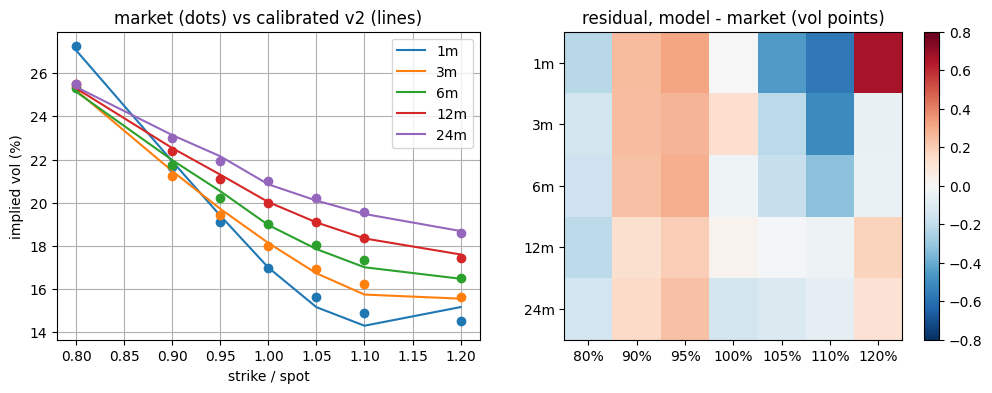

,80%,90%,95%,100%,105%,110%,120%
1m,-0.22,0.25,0.31,-0.00,-0.45,-0.57,0.66
3m,-0.15,0.25,0.27,0.13,-0.22,-0.51,-0.06
6m,-0.17,0.24,0.29,-0.03,-0.18,-0.33,-0.06
12m,-0.21,0.13,0.20,0.03,-0.01,-0.04,0.18
24m,-0.15,0.15,0.23,-0.15,-0.12,-0.08,0.11


,market 90-110 skew,model 90-110 skew,market butterfly,model butterfly
1m,6.78,7.61,1.27,1.12
3m,4.96,5.72,0.74,0.47
6m,4.40,4.96,0.54,0.53
12m,4.01,4.18,0.39,0.41
24m,3.42,3.65,0.27,0.45


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, m in enumerate(MATS):
    ax[0].plot(STRIKES, 100 * MARKET[i], 'o', color=f'C{i}'); ax[0].plot(STRIKES, 100 * IV_FIT[m], '-', color=f'C{i}', label=f'{m}m')
ax[0].set_title('market (dots) vs calibrated v2 (lines)'); ax[0].set_xlabel('strike / spot'); ax[0].set_ylabel('implied vol (%)'); ax[0].legend()
im = ax[1].imshow(100 * resid, cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
ax[1].set_xticks(range(len(STRIKES))); ax[1].set_xticklabels([f'{int(100*k)}%' for k in STRIKES]); ax[1].set_yticks(range(len(MATS))); ax[1].set_yticklabels([f'{m}m' for m in MATS])
ax[1].set_title('residual, model - market (vol points)'); plt.colorbar(im, ax=ax[1]); ax[1].grid(False); plt.show()
display(pd.DataFrame(100 * resid, index=[f'{m}m' for m in MATS], columns=[f'{int(100*k)}%' for k in STRIKES]).round(2))
pd.DataFrame({'market 90-110 skew': [skew_90_110(MARKET[i]) for i in range(len(MATS))], 'model 90-110 skew': [skew_90_110(IV_FIT[m]) for m in MATS],
              'market butterfly': [bfly_90_110(MARKET[i]) for i in range(len(MATS))], 'model butterfly': [bfly_90_110(IV_FIT[m]) for m in MATS]}, index=[f'{m}m' for m in MATS]).round(2)


**Reading the fit.** A quarter of a vol point RMSE over 35 quotes, the same order as the first
edition, with a structural pattern worth naming: the fitted **fast leverage is zero**. The NIG residual
reproduces the spot skew on its own, so the calibrator had no use for $\rho_s$ — which is the
identification statement of 5.2 made concrete: vanillas cannot tell residual skew from leverage skew.
Nothing about the spot smile is wrong; what is undetermined is the forward smile, and 5.5 measures
it. The slow factor sits at the stationary-spread cap and carries the long-dated skew, as in v1; its
vol-of-vol is what the surface's var-swap/ATM gap of 4.7 points at 2y demands. The curve check is the
new result: the fitted $\xi$ tracks the replicated variance-swap strip segment by segment, which the
first edition's log-level curve could not be compared with at all.


### 5.4 Sizing diagnostics

The checks that catch a fit that is right for the wrong reasons. Two are new: the residual's
**conditioning share** $\gamma^2/\alpha^2$ and the **effective conditioning share**
$c_{\text{eff}} = c\cdot\gamma^2/\alpha^2$, which is what the OSS efficiency actually depends on now
that the mixer takes part of the residual's variance out of the Gaussian.


In [14]:
c_fit = 1 - P_FIT['rho_s'] ** 2 - P_FIT['rho_l'] ** 2; cond_fit = 1 - (P_FIT['beta'] / P_FIT['alpha']) ** 2; c_eff = c_fit * cond_fit
g3 = Grid(n_blocks=36); Pn, Ln = unpack(x3, P, g3); d3 = draws(g3, 2 ** 14, np.random.default_rng(9))
phi_l, phi_s, w_l, w_s = ou_coeffs(Pn, g3.dt); ell = np.full(2 ** 14, Ln[0]); s = np.zeros(2 ** 14); near = 0; maxv = -np.inf
for k in range(g3.n_steps):
    xk = ell + s; near += np.mean((Pn['cap_a'] - xk) / Pn['cap_beta'] < 5); maxv = max(maxv, xk.max())
    s = phi_s * s + w_s * d3['eta_s'][:, k]; ell = Ln[k + 1] + phi_l * (ell - Ln[k]) + w_l * d3['eta_l'][:, k]
near /= g3.n_steps
mo1, mo12 = nig_moments(c_fit * XI_FIT[0] / 12, P_FIT['alpha'], P_FIT['beta']), nig_moments(c_fit * XI_FIT[3], P_FIT['alpha'], P_FIT['beta'])
diag = pd.DataFrame([
    ['fast leverage product rho_s*sigma_s', P_FIT['rho_s'] * P_FIT['sigma_s'], 'index skew needs about -1.2 to -2.5 across the two factors; here the residual took the job'],
    ['slow leverage product rho_l*sigma_l', P_FIT['rho_l'] * P_FIT['sigma_l'], ''],
    ['idiosyncratic share c', c_fit, '>= 0.12'],
    ['residual conditioning share gamma^2/alpha^2', cond_fit, '>= 0.40'],
    ['effective conditioning share c_eff', c_eff, 'OSS efficiency vs one-day truncation ~ (sqrt(c_eff)/0.22)^3'],
    ['OSS efficiency factor', (np.sqrt(c_eff) / 0.22) ** 3, 'second-order noise, monthly blocks'],
    ['residual skewness at 1m / 1y', f"{mo1['skew']:.2f} / {mo12['skew']:.2f}", 'Levy scaling in the clock'],
    ['residual shape alpha*delta at 1m / 1y', f"{mo1['abar']:.2f} / {mo12['abar']:.2f}", '~1 strongly non-Gaussian, ~15 nearly Gaussian'],
    ['stationary sd of log-vol', stationary_logvol_sd(P_FIT), '0.4 - 0.9 (VIX options at one year)'],
    ['fraction of path-days within 5 widths of the cap', near, '< 1e-5'],
    ['highest log-variance reached (vol %)', 100 * np.exp(0.5 * maxv), f'cap at {100*np.exp(0.5*Pn["cap_a"]):.0f}%'],
], columns=['diagnostic', 'value', 'reference']).set_index('diagnostic')
diag


,value,reference
diagnostic,,
fast leverage product rho_s*sigma_s,-0.0,index skew needs about -1.2 to -2.5 across the...
slow leverage product rho_l*sigma_l,-0.9163,
idiosyncratic share c,0.7241,>= 0.12
residual conditioning share gamma^2/alpha^2,0.7122,>= 0.40
effective conditioning share c_eff,0.5157,OSS efficiency vs one-day truncation ~ (sqrt(c...
OSS efficiency factor,34.7811,"second-order noise, monthly blocks"
residual skewness at 1m / 1y,-0.89 / -0.18,Levy scaling in the clock
residual shape alpha*delta at 1m / 1y,3.90 / 99.54,"~1 strongly non-Gaussian, ~15 nearly Gaussian"
stationary sd of log-vol,0.9001,0.4 - 0.9 (VIX options at one year)


### 5.5 Forward skew: measured in differences, steered by calendar time

The first edition established three facts that this edition inherits without re-arguing: vanillas do
not pin the forward smile; state-dependent parameters do not move it (three levers tried, none moved
the stickiness ratio); calendar-time buckets do. Two refinements from the calibration work since:

* **Measure differences, not ratios.** The stickiness ratio ψ divides by the spot quantity, which for
  the butterfly at 3–6 months (and for the skew on any symmetric FX smile) is within a few tenths of a
  vol point of zero — a quotient of noise. The targets are $\Delta_{\text{skew}} = $ forward skew − spot
  skew and $\Delta_{\text{bfly}} = $ forward butterfly − spot butterfly, in vol points, at the same
  tenor; sticky-delta is both at zero. Ratios are reported only where the spot quantity exceeds half a
  vol point.
* **Both matter, because the two ingredients have opposite signatures.** Residual skew is sticky in
  vol points (a Lévy law on the clock has skewness $\propto A^{-1/2}$ and vol $\propto A^{1/2}$) and its
  convexity dilutes at the forward date; leverage skew dilutes and vol-of-vol convexity *amplifies*
  through state mixing. Skew alone cannot separate $\beta$ from vol-of-vol; the pair can.

The forward-start option $(S_{T_2}/S_{T_1}-k)^+$ is priced by the same conditional Black on the block
$[T_1,T_2]$ after walking the state to $T_1$. Below: the vanilla-calibrated model, then the two
calendar-time levers — a steeper residual skew $\beta$ after year one, and a fast leverage $\rho_s$
switched on after year one (recall the vanilla fit set it to zero) — each with its 2y composition
residual, the price the 2y vanillas pay.


In [15]:
def forward_smile(W, grid, t1_block, dT_blocks, strikes):
    Mb = W['M'][:, t1_block:t1_block + dT_blocks].sum(1); S2b = W['S2'][:, t1_block:t1_block + dT_blocks].sum(1)
    F, sd = np.exp(Mb + 0.5 * S2b), np.sqrt(S2b); T = dT_blocks * grid.block_days / DAYS
    return np.array([implied_vol_otm((black_put(F, k, sd) if k < 1.0 else black(F, k, sd)).mean(), 1.0, k, T, k < 1.0) for k in strikes])

grid = Grid(n_blocks=24); d_fwd = draws(grid, 2 ** 14, np.random.default_rng(12))
def stickiness_row(label, **kw):
    Wk = walk(grid, P_FIT, L_FIT, d_fwd, **kw)
    sp = model_smile(Wk, 1.0, grid, [12, 24], STRIKES); fw = forward_smile(Wk, grid, 12, 12, STRIKES)
    return [label, skew_90_110(sp[12]), skew_90_110(fw), skew_90_110(fw) - skew_90_110(sp[12]), skew_90_110(fw) / skew_90_110(sp[12]),
            bfly_90_110(sp[12]), bfly_90_110(fw), bfly_90_110(fw) - bfly_90_110(sp[12]),
            skew_90_110(sp[24]), skew_90_110(MARKET[4]), 100 * np.sqrt(np.nanmean((sp[24] - MARKET[4]) ** 2))]
rows = [stickiness_row('vanilla calibration (one bucket)'),
        stickiness_row('beta steeper after year one (-38)', beta_t=bucket_on_grid(grid, np.array([0.0, 1.0]), [P_FIT['beta'], -38.0])),
        stickiness_row('rho_s = -0.5 after year one', rho_s_t=bucket_on_grid(grid, np.array([0.0, 1.0]), [P_FIT['rho_s'], -0.5]))]
STICK = pd.DataFrame(rows, columns=['calibration', 'spot 1y skew', 'fwd 1y-into-1y skew', 'delta skew', 'psi_skew', 'spot 1y bfly', 'fwd bfly', 'delta bfly',
                                    '2y skew model', '2y skew market', '2y residual RMSE']).set_index('calibration')
STICK.round(3)


,spot 1y skew,fwd 1y-into-1y skew,delta skew,psi_skew,spot 1y bfly,fwd bfly,delta bfly,2y skew model,2y skew market,2y residual RMSE
calibration,,,,,,,,,,
vanilla calibration (one bucket),4.055,3.563,-0.492,0.879,0.382,0.986,0.605,3.178,3.418,0.343
beta steeper after year one (-38),4.055,3.768,-0.287,0.929,0.382,0.954,0.572,3.209,3.418,0.361
rho_s = -0.5 after year one,4.055,3.999,-0.056,0.986,0.382,0.755,0.374,3.230,3.418,0.498


The vanilla-calibrated v2 sits at a skew difference of about half a vol point below sticky (ψ ≈ 0.88;
v1 read 0.86 on the same surface), and its forward butterfly is *higher* than the spot one — the
state-mixing amplification of convexity, which is the vol-of-vol's signature and exactly why the
butterfly difference is in the target. Either lever moves the forward skew to sticky-delta or beyond;
the $\rho_s$ lever costs more in the 2y vanillas than the $\beta$ lever, because leverage skew and
residual skew compose differently into the 2y smile. On a real market these numbers come from
forward-start quotes or a reference model; on this stylised one they are the desk question, priced
in section 6.


## 6. Pricing the autocall

The pricer from section 2 on the calibrated model's block Gaussians over the deal's own 36-block grid.
OSS and brute force share the variance path *and* the mixer, so the paired comparison isolates the
fire/survive treatment; the forward-skew sensitivity is a paired difference on the same draws.


In [16]:
grid = Grid(n_blocks=N_OBS); P_deal, L_deal = unpack(x3, P, grid)
d_deal = draws(grid, 2 ** 15, np.random.default_rng(21))
rho_t_deal = bucket_on_grid(grid, np.array([0.0, 1.0]), [P_FIT['rho_s'], -0.5])
rows, pvs = [], {}
for label, kw in [('one bucket (vanillas only)', {}), ('two buckets (rho_s = -0.5 after year one)', dict(rho_s_t=rho_t_deal))]:
    Wd = walk(grid, P_deal, L_deal, d_deal, **kw)
    pv_o = autocall_oss_from_stats(Wd['M'], Wd['S2'], d_deal['u_block'], 1.0, TRIGGER, BARRIER, COUPON)
    pv_b = autocall_brute_from_returns(Wd['M'] + np.sqrt(Wd['S2']) * d_deal['eps'], 1.0, TRIGGER, BARRIER, COUPON)
    pvs[label] = pv_o; rows.append([label, 'OSS', pv_o.mean(), se(pv_o)]); rows.append([label, 'brute force', pv_b.mean(), se(pv_b)])
res_tab = pd.DataFrame(rows, columns=['calibration', 'estimator', 'value (of notional)', 'std error']).set_index(['calibration', 'estimator'])
paired = pvs['two buckets (rho_s = -0.5 after year one)'] - pvs['one bucket (vanillas only)']
print(f"forward-skew sensitivity, paired on the same draws: {paired.mean():+.5f} +- {se(paired):.5f} = {100*paired.mean()/abs(pvs['one bucket (vanillas only)'].mean()):+.1f}% of value")
res_tab.round(5)


forward-skew sensitivity, paired on the same draws: +0.00064 +- 0.00033 = +2.1% of value


value (of notional)  \
calibration                               estimator                          
one bucket (vanillas only)                OSS                       0.0311   
                                          brute force               0.0301   
two buckets (rho_s = -0.5 after year one) OSS                       0.0318   
                                          brute force               0.0305   

                                                       std error  
calibration                               estimator               
one bucket (vanillas only)                OSS             0.0006  
                                          brute force     0.0009  
two buckets (rho_s = -0.5 after year one) OSS             0.0006  
                                          brute force     0.0009

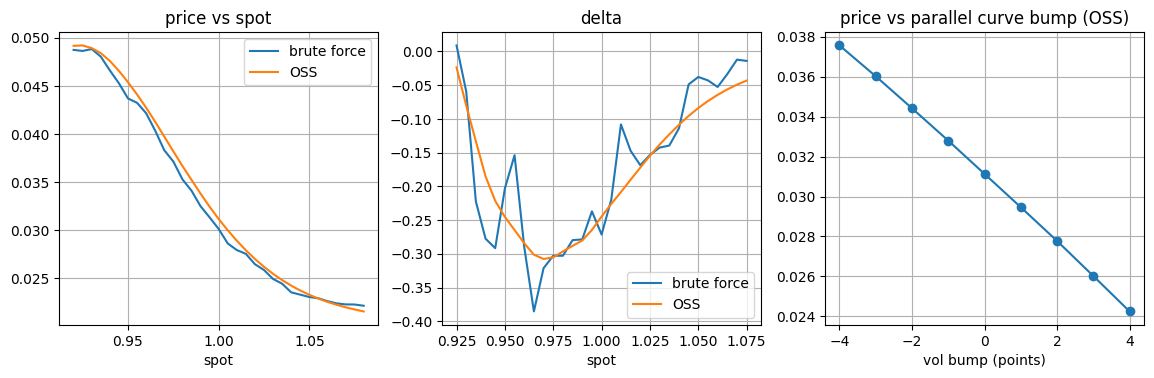

delta at spot (OSS): -0.2448 per unit spot   (small and negative at the trigger: a higher spot calls the note earlier for a smaller accrued coupon)
vega (OSS): -0.00167 per vol point of the curve


In [17]:
Wd = walk(grid, P_deal, L_deal, d_deal)
spots = np.linspace(0.92, 1.08, 33)
oss_l = [autocall_oss_from_stats(Wd['M'], Wd['S2'], d_deal['u_block'], s_, TRIGGER, BARRIER, COUPON).mean() for s_ in spots]
bru_l = [autocall_brute_from_returns(Wd['M'] + np.sqrt(Wd['S2']) * d_deal['eps'], s_, TRIGGER, BARRIER, COUPON).mean() for s_ in spots]
bumps = np.linspace(-0.04, 0.04, 9); vega_l = []
for bmp in bumps:                                                    # parallel bump of the forward-variance curve in vol terms
    xb = x3.copy(); xb[:5] = np.log((np.sqrt(np.exp(x3[:5])) + bmp) ** 2)
    Pb, Lb = unpack(xb, P, grid); Wb = walk(grid, Pb, Lb, d_deal)
    vega_l.append(autocall_oss_from_stats(Wb['M'], Wb['S2'], d_deal['u_block'], 1.0, TRIGGER, BARRIER, COUPON).mean())
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(spots, bru_l, label='brute force'); ax[0].plot(spots, oss_l, label='OSS'); ax[0].set_title('price vs spot'); ax[0].legend(); ax[0].set_xlabel('spot')
ax[1].plot(spots[1:-1], np.gradient(bru_l, spots)[1:-1], label='brute force'); ax[1].plot(spots[1:-1], np.gradient(oss_l, spots)[1:-1], label='OSS'); ax[1].set_title('delta'); ax[1].legend(); ax[1].set_xlabel('spot')
ax[2].plot(100 * bumps, vega_l, 'o-'); ax[2].set_title('price vs parallel curve bump (OSS)'); ax[2].set_xlabel('vol bump (points)'); plt.show()
print(f"delta at spot (OSS): {(oss_l[17]-oss_l[15])/(spots[17]-spots[15]):+.4f} per unit spot   (small and negative at the trigger: a higher spot calls the note earlier for a smaller accrued coupon)")
print(f"vega (OSS): {(vega_l[5]-vega_l[3])/(2*0.01)*0.01:+.5f} per vol point of the curve")


## 7. The validation gates

The first edition's gates, with the residual's own added: the IG moment-generating identity inside the
martingale, the semigroup, the mixture identity, the Esscher-tilt oracle, the mixer's quantile round
trip, and the admissibility map.


In [18]:
gates = []
cM, cS2 = np.cumsum(Wd['M'], 1), np.cumsum(Wd['S2'], 1); F3 = np.exp(cM[:, -1] + 0.5 * cS2[:, -1])
gates.append(['G1  martingale E[S_3y] = 1', f'{F3.mean()-1:+.4f} +- {se(F3):.4f}', 'within 3 se'])
# G1b: the residual's martingale identity in closed form: E_G[exp(mu_A + (beta + 1/2) G)] = 1 via the IG MGF
def ig_mgf(t, m, lam):
    return np.exp(lam / m * (1 - np.sqrt(1 - 2 * m ** 2 * t / lam)))
A_t = 0.01; dl, mu_, gm = nig_budget(A_t, P_FIT['alpha'], P_FIT['beta'])
gates.append(['G1b residual E[exp(X_A)] = 1 by the IG MGF (closed form)', f"{np.exp(mu_) * ig_mgf(P_FIT['beta'] + 0.5, dl/gm, dl**2):.12f}", '1 to 1e-12'])
gates.append(['G2  semigroup: split clock = one clock', f'KS = {ks_semi.statistic:.4f}, p = {ks_semi.pvalue:.2f}', 'p > 0.01'])
g6 = Grid(block_days=42, n_blocks=18, n_sub=6); W6 = walk(g6, P_deal, L_deal, dict(d_deal, uG=d_deal['uG'][:, :18]))
gates.append(['G3  composability (2 x 21d = 1 x 42d: M_lev, A)', f'max |dM_lev| = {np.abs(W6["Mlev"] - (Wd["Mlev"][:, ::2] + Wd["Mlev"][:, 1::2])).max():.1e}, max |dA| = {np.abs(W6["A"] - (Wd["A"][:, ::2] + Wd["A"][:, 1::2])).max():.1e}', '< 1e-12'])
v = res_tab.loc[('one bucket (vanillas only)', 'OSS')]; b = res_tab.loc[('one bucket (vanillas only)', 'brute force')]
gates.append(['G4  OSS = brute force', f'diff {v.iloc[0]-b.iloc[0]:+.5f} vs se {np.hypot(v.iloc[1], b.iloc[1]):.5f}', 'within 3 se'])
nn_ = Wd['M'].shape[0]; logS = np.zeros(nn_); Lw = np.ones(nn_); fired_total = np.zeros(nn_)
for j in range(N_OBS):
    m_, sd_ = Wd['M'][:, j], np.sqrt(Wd['S2'][:, j]); p_ = Phi((np.log(TRIGGER) - logS - m_) / sd_)
    fired_total += Lw * (1 - p_); Lw *= p_; logS += m_ + sd_ * Phinv(np.clip(d_deal['u_block'][:, j] * p_, 1e-16, 1 - 1e-16))
gates.append(['G5  survival ledger conserved', f'max |fired + alive - 1| = {np.abs(fired_total + Lw - 1).max():.1e}', '< 1e-12'])
# G6: Esscher-tilt oracle vs mixture MC on one residual period
def nig_cdf_(x, a, b_, dl_, mu2): return norminvgauss.cdf(x, a * dl_, b_ * dl_, loc=mu2, scale=dl_)
K_ = 0.95; A6 = 0.01; dl6, mu6, gm6 = nig_budget(A6, P_FIT['alpha'], P_FIT['beta'])
closed = (1 - nig_cdf_(np.log(K_), P_FIT['alpha'], P_FIT['beta'] + 1, dl6, mu6)) - K_ * (1 - nig_cdf_(np.log(K_), P_FIT['alpha'], P_FIT['beta'], dl6, mu6))
rng6 = np.random.default_rng(6); G6_, _ = nig_mixer(A6, P_FIT['alpha'], P_FIT['beta'], rng6.uniform(size=400_000)); X6 = mu6 + P_FIT['beta'] * G6_ + np.sqrt(G6_) * rng6.standard_normal(400_000)
mc6 = np.maximum(np.exp(X6) - K_, 0.0)
gates.append(['G6  residual Esscher oracle vs mixture MC (95% call)', f'{closed:.5f} vs {mc6.mean():.5f} +- {se(mc6):.5f}', 'within 3 se'])
P_gbm = dict(P_FIT, sigma_s=1e-9, sigma_l=1e-9, rho_s=0.0, rho_l=0.0, alpha=2e4, beta=-0.5)
gg = Grid(n_blocks=12); Wg = walk(gg, P_gbm, Lstar_on_grid(gg, P_gbm, xi_on_grid(gg, SEG_END, np.full(5, 0.04))), draws(gg, 4096, np.random.default_rng(8)))
iv_g = model_smile(Wg, 1.0, gg, [12], STRIKES)[12]
gates.append(['G7  Gaussian limit (alpha -> inf, no leverage) reproduces flat 20% vol', f'max |iv - 20%| = {100*np.nanmax(np.abs(iv_g - 0.2)):.2e} vol pts', '< 1e-3'])
import inspect; src = inspect.getsource(walk)
gates.append(['G8  no clamp/floor on any variance quantity in walk()', 'none found' if 'clip' not in src and 'maximum' not in src else 'FOUND', 'none'])
gates.append(['G12 mixer quantile round trip', f'{np.max(np.abs(ig_cdf(G, delta/gamma, delta**2) - u)):.1e}', '< 1e-10'])
rr = np.random.default_rng(15).uniform(-10, 10, size=(100_000, 2)); aa, bb = nig_ab(rr[:, 0], rr[:, 1])
gates.append(['G15 admissibility map: |beta+1| < alpha and |beta| < alpha on 1e5 random points', f'{bool(np.all(np.abs(bb + 1) < aa) and np.all(np.abs(bb) < aa))}', 'True'])
pd.DataFrame(gates, columns=['gate', 'measured', 'pass mark']).set_index('gate')


,measured,pass mark
gate,,
G1 martingale E[S_3y] = 1,-0.0014 +- 0.0014,within 3 se
G1b residual E[exp(X_A)] = 1 by the IG MGF (closed form),1.000000000000,1 to 1e-12
G2 semigroup: split clock = one clock,"KS = 0.0016, p = 0.71",p > 0.01
"G3 composability (2 x 21d = 1 x 42d: M_lev, A)","max |dM_lev| = 4.4e-16, max |dA| = 4.4e-16",< 1e-12
G4 OSS = brute force,diff +0.00104 vs se 0.00112,within 3 se
G5 survival ledger conserved,max |fired + alive - 1| = 7.8e-16,< 1e-12
G6 residual Esscher oracle vs mixture MC (95% call),0.06937 vs 0.06934 +- 0.00011,within 3 se
"G7 Gaussian limit (alpha -> inf, no leverage) reproduces flat 20% vol",max |iv - 20%| = 1.42e-07 vol pts,< 1e-3
G8 no clamp/floor on any variance quantity in walk(),none found,none


**G9 — what the daily chain commits to.** The residual is partition-invariant given its clock, so
refining the internal step can only move the *state chain* — the clock it integrates and the leverage
it accrues. The table repeats the first edition's step-size experiment. Vanilla vols settle by the
7-day step, as before. The autocall's step dependence is smaller than v1's: the monthly step is
several percent off, but the 7-, 3- and 1-day values agree within Monte Carlo error here, where v1
still moved by about 5% between 7 days and 1 day. That is what a residual carrying the skew with a
partition-invariant law buys. The production rule does not change — the day is the model, and this
notebook uses 7 days for speed — but the reason for it has shifted from the residual to the state.


In [19]:
rows = []
for n_sub in [1, 3, 7, 21]:
    g = Grid(n_blocks=N_OBS, n_sub=n_sub); Pg, Lg = unpack(x3, P, g)
    dg = draws(g, 2 ** 16, np.random.default_rng(5)); Wg = walk(g, Pg, Lg, dg)
    pv = autocall_oss_from_stats(Wg['M'], Wg['S2'], dg['u_block'], 1.0, TRIGGER, BARRIER, COUPON); iv = model_smile(Wg, 1.0, g, [12], STRIKES)[12]
    rows.append([f'{21//n_sub} days', pv.mean(), se(pv), 100 * iv[3], 100 * iv[1]])
G9 = pd.DataFrame(rows, columns=['internal step', 'autocall value', 'std error', '1y ATM vol (%)', '1y 90% vol (%)']).set_index('internal step')
G9.round(4)


,autocall value,std error,1y ATM vol (%),1y 90% vol (%)
internal step,,,,
21 days,0.0329,0.0004,19.8220,22.0390
7 days,0.0306,0.0004,20.0460,22.4047
3 days,0.0311,0.0004,20.0716,22.4974
1 days,0.0303,0.0004,20.1358,22.5036


## 8. v1 and v2 side by side, and what to remember

The first edition's numbers below are copied from its executed run on the same market, product, grid
and seeds; the v2 numbers are from this run.


In [20]:
v1 = {'vanilla RMSE (vol pts)': 0.26, 'fast leverage product': -0.50, 'idiosyncratic share c': 0.587, 'effective conditioning share': 0.587,
      'stickiness psi (skew), vanilla fit': 0.855, 'forward-skew sensitivity of the deal': 0.021, 'autocall value, OSS (one bucket)': 0.02736, 'autocall std error, OSS': 0.00060,
      'autocall std error, brute force': 0.00093, 'non-differentiable parameters': 1, 'roots per path per block': 0}
v2 = {'vanilla RMSE (vol pts)': 100 * np.sqrt(np.nanmean(resid ** 2)), 'fast leverage product': P_FIT['rho_s'] * P_FIT['sigma_s'], 'idiosyncratic share c': c_fit, 'effective conditioning share': c_eff,
      'stickiness psi (skew), vanilla fit': STICK.iloc[0]['psi_skew'], 'forward-skew sensitivity of the deal': paired.mean() / abs(pvs['one bucket (vanillas only)'].mean()),
      'autocall value, OSS (one bucket)': v.iloc[0], 'autocall std error, OSS': v.iloc[1], 'autocall std error, brute force': b.iloc[1], 'non-differentiable parameters': 0, 'roots per path per block': 1}
pd.DataFrame({'v1 (Poisson residual)': v1, 'v2 (NIG residual)': v2}).round(4)


,v1 (Poisson residual),v2 (NIG residual)
vanilla RMSE (vol pts),0.2600,0.2546
fast leverage product,-0.5000,-0.0000
idiosyncratic share c,0.5870,0.7241
effective conditioning share,0.5870,0.5157
"stickiness psi (skew), vanilla fit",0.8550,0.8787
forward-skew sensitivity of the deal,0.0210,0.0207
"autocall value, OSS (one bucket)",0.0274,0.0311
"autocall std error, OSS",0.0006,0.0006
"autocall std error, brute force",0.0009,0.0009
non-differentiable parameters,1.0000,0.0000


**Reading the comparison.** Two things the table says that no single notebook could. The two
editions agree on every vanilla to a quarter of a vol point and on the forward-skew *sensitivity*
of the deal (+2.1% both), and yet they price the autocall 13% apart. That gap is not an error in
either: it is the split of today's skew between residual and leverage, which v1 gave mostly to jumps
plus some fast leverage and v2 gave entirely to the residual, and which no vanilla can see. The
forward-smile target of 5.5 is what would make the two editions agree on the autocall — a point the
first edition argued and this table demonstrates. And v2's estimator is no worse for the swap: the
OSS standard error is unchanged, the effective conditioning share is comparable, and there is no
longer a parameter the Greeks cannot reach.

**What to remember**

1. **Same architecture, one residual swapped.** State, leverage, curve, cap, OSS pricer, gates: all
   shared. v1's residual was a Gaussian with a Poisson mixer; v2's is a Gaussian with an
   inverse-Gaussian mixer. Both compose exactly in the clock; only the mixer's law differs.
2. **The curve is now the market's object.** Store $\xi=E[h]$, derive $L^*$ with the Jensen term inside
   the model, keep it flat per segment, and check it against the variance-swap strip. The ATM level is
   then invariant to vol-of-vol by construction.
3. **Every parameter is a Greek.** The shape $(\alpha,\beta)$ is identified and smooth, the drift is
   forced, the admissibility map makes every iterate finite, and the mixer's quantile carries an
   implicit-function derivative. The price is one monotone root per block, never in the return's CDF.
4. **Watch the conditioning share.** The mixer keeps $\gamma^2/\alpha^2$ of the residual's variance in
   the Gaussian; $c_{\text{eff}} = c\,\gamma^2/\alpha^2$ is what OSS efficiency depends on, and
   $|\beta|/\alpha \le 0.77$ is the guard.
5. **Vanillas still don't close the model.** Here they set the fast leverage to zero and let the
   residual carry the skew — a legitimate spot fit and an undetermined forward smile. Measure forward
   skew in differences, target it from forward-start quotes, a reference model, or a sticky-delta prior,
   and steer it with calendar-time buckets of $\beta$ or $\rho_s$; the 2y composition residual is the
   honest price.
6. **Every claim has a gate**, and the residual's own identities — variance budget, forced drift,
   semigroup, mixture, Esscher oracle, quantile round trip, admissibility — are among them.

*Classical pieces:* Barndorff-Nielsen (1997) for the NIG law and its mixture form; Romano–Touzi and
Willard for conditioning on the variance path; Glasserman & Staum (2001) for one-step survival;
Bergomi (2016) for forward-variance thinking; Gatheral & Jacquier (2014) for the SVI surface.
